## Ex 1 -- Advanced Exercise 1 
_Using `PolynomialFeatures`_

<br>
<br>




### Dataset: [Human Resources Data](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set)

|Parameter|Description|
|---|---|
|Shape|`_311 rows, 35 columns_`|
|Target Variable|`_Salary_`|
|Method:|`_LinearRegressor_` using `_PolynomialFeatures_`
|Extra Tools:|`_Mlflow_`|
|Columns Descriptions|_Not available_|

#### Summary:
Let's try to use `PolynomialFeatures` with `LinearRegression` for this dataset. I decided to pick a salary dataset because I feel it may have a ton of features that may make it fluctuate wildly, which hopefully creates some curved features instead of a line. The big challenge will be the amount of rows available. Lets give it a shot, I may regret this later.

#### Results:

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

Here's a comparison of the model results using `PolynomialFeatures` and not using it.

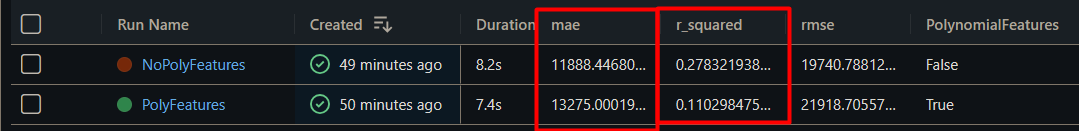

Long story short, my results with using `PolynomialFeatures` aren't great for this dataset. 

Theory for the reasons:

1. Not enough rows. You can't visualize a curved line if you don't have enough rows.
2. Too much variance. The y_test vs. predicted has a ton of variance -- That confuses curves in lines.
3. `PolynomialFeatures` is limited depending on the number of features . If we have a ton of features for `X` , it would explode the dataset and I would run out of RAM _(Think multiplying a polynomial with 5 degrees in math to another polynomial with 5 degrees, that's a HUGE result)_
4. There might be something I'm doing wrong.

Though, overall -- The results of the dataset were remarkably better than my basic ex1 project.
</div>






## Code

#### Imports and Loading Dataset

In [338]:
# Import s
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import datetime as dt
import mlflow
import warnings
warnings.filterwarnings('ignore') 

df = pd.read_csv("datasets/hr_data.csv")
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,1/25/2019,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16


### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation & Feature Engineering|
|3| ML Implementation|


In [339]:
# Let's check the rows and columns
df.shape

# Oh boy, that's not a lot of data. Let's hope there isn't a strong skew for
# the target variable.

(311, 36)

#### Missing Data Handling

In [340]:
# Let's take a look at the null values.
df.isna().sum()

# We have missing termination values. Let's drop them.
# REASON: I can't foresee it being useful in predicting salary. 

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [341]:
# Dropping the `DateofTermination` column.
df = df.drop("DateofTermination", axis=1)

#### Duplicates Handling

In [342]:
# Let's check for duplicates
df.duplicated().value_counts()

False    311
Name: count, dtype: int64

#### Dropping Unnecessary Columns

In [343]:
# Now, we'll drop some columns that will cause problems later. 
# NOTE: I'm planning to keep this dataset rather simple! 

df = df.drop([
    "EmpID",             # Likely doesn't related to `Salary`
    "Employee_Name",     # Likely not related to `Salary`
    "Sex",               # Let's not discriminate!
    "HispanicLatino",    # Let's not discriminate!
    "RaceDesc",          # Let's not discriminate!
    "CitizenDesc",       # Let's not discriminate!
    "DeptID",            # Co-cardinality with `Department`
    "TermReason",        # FAR too many value options to convert to numbers
    "ManagerName",       # Co-cardinality with `ManagerID`
    "ManagerID",         # Likely too much information. We don't have enough rows to filter.
    "PositionID",        # Co-cardinatlity with `PositionID`
    "EmploymentStatus",  # Too many value options to convert to numbers
    "Position",          # # Too many value options to convert to numbers. We don't have enough rows to filter.
    "Zip",               # Likely no related to `Salary`
    "Termd",             # I'm not sure what this is so I can't confirm co-cardinality.
    "PerformanceScore",  # Co-cardinality with `PerfScoreID`
    "EmpStatusID",       # Will create too many features. 
], axis=1)


#### Converting Binary Columns to Numbers

In [344]:
df.head(3)

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,State,DOB,MaritalDesc,DateofHire,Department,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,0,0,1,4,0,62506,MA,07/10/83,Single,7/5/2011,Production,LinkedIn,4.60,5,0,1/17/2019,0,1
1,1,1,1,3,0,104437,MA,05/05/75,Married,3/30/2015,IT/IS,Indeed,4.96,3,6,2/24/2016,0,17
2,1,1,0,3,0,64955,MA,09/19/88,Married,7/5/2011,Production,LinkedIn,3.02,3,0,5/15/2012,0,3


#### Checking Categorical Roles

In [345]:
# Let's look and see what kind of values the `state` column looks like.
df['State'].value_counts()

# That's going to be a problem. If we put this into OneHotEncoder, we'd
# have a ton of weights determined by a single case. Let's drop the column.

State
MA    276
CT      6
TX      3
VT      2
VA      1
AL      1
WA      1
CA      1
OH      1
IN      1
TN      1
NH      1
RI      1
PA      1
CO      1
NY      1
UT      1
GA      1
FL      1
NC      1
KY      1
ID      1
NV      1
MT      1
OR      1
ND      1
AZ      1
ME      1
Name: count, dtype: int64

In [346]:
# Dropping the `State` column.
df = df.drop("State", axis=1)
df.head(3)

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,DOB,MaritalDesc,DateofHire,Department,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,0,0,1,4,0,62506,07/10/83,Single,7/5/2011,Production,LinkedIn,4.60,5,0,1/17/2019,0,1
1,1,1,1,3,0,104437,05/05/75,Married,3/30/2015,IT/IS,Indeed,4.96,3,6,2/24/2016,0,17
2,1,1,0,3,0,64955,09/19/88,Married,7/5/2011,Production,LinkedIn,3.02,3,0,5/15/2012,0,3


In [347]:
# Checking the value counts for the `MaritalDesc` column.
df['MaritalDesc'].value_counts()

# This seems fine. It'll only create 5 more columns.

MaritalDesc
Single       137
Married      124
Divorced      30
Separated     12
Widowed        8
Name: count, dtype: int64

In [348]:
# Checking the value counts for the `RecruitmentSource` column.
df['RecruitmentSource'].value_counts()

# Looks like there are only a couple rows which might be a problem
# when turning them into a numbers. Let's get rid of them.

RecruitmentSource
Indeed                     87
LinkedIn                   76
Google Search              49
Employee Referral          31
Diversity Job Fair         29
CareerBuilder              23
Website                    13
Other                       2
On-line Web application     1
Name: count, dtype: int64

In [349]:
# Using multi-filtering to get rid of the `Other` and
# `On-line Web Application` values in the `RecruitmentSource` column.
df = df[
    (df["RecruitmentSource"] != "On-line Web application") |
    (df["RecruitmentSource"] != "Other")
   ] 

#### Handling the Date Columns

My overall strategy here will be to turn the dates into nominal column instead. YYYYMMDD format, where a later date is a higher number.

In [350]:
# Converting the date column to datetime and transforming it into YYYYMMDD format.
date_columns = ["DOB", "DateofHire", "LastPerformanceReview_Date"]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], infer_datetime_format=True)
    df[column] = df[column].dt.strftime("%Y%m%d").astype(int)

df.head(3)

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,DOB,MaritalDesc,DateofHire,Department,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,0,0,1,4,0,62506,19830710,Single,20110705,Production,LinkedIn,4.60,5,0,20190117,0,1
1,1,1,1,3,0,104437,20750505,Married,20150330,IT/IS,Indeed,4.96,3,6,20160224,0,17
2,1,1,0,3,0,64955,19880919,Married,20110705,Production,LinkedIn,3.02,3,0,20120515,0,3


#### Checking Date Column Ranges (Do they make sense?)

In [351]:
# Let's check some of these DOB values.
df.sort_values("DOB", ascending=False)

# OK. That's a problem. Last time I checked, 2075 isn't a REAL Date of Birth.
# We're doing to have to drop this column. I am hoping this isn't synthetic data.

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,DOB,MaritalDesc,DateofHire,Department,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
54,0,2,1,2,0,68051,20751217,Divorced,20100720,Production,CareerBuilder,4.13,2,0,20190114,3,3
67,0,0,1,1,0,61568,20751102,Single,20140929,Sales,Indeed,1.93,3,0,20190130,6,5
173,1,1,0,3,0,52057,20751022,Married,20150216,Production,Website,5.00,3,0,20190123,0,6
264,1,1,0,3,0,65714,20750930,Married,20121002,Production,LinkedIn,4.83,5,0,20190214,0,15
280,0,4,1,3,0,67176,20750916,Widowed,20070625,Production,Other,4.10,4,0,20100714,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,0,2,0,3,0,68182,19760922,Divorced,20110221,Production,Google Search,3.72,3,0,20130201,0,18
186,0,0,0,3,0,55688,19760922,Single,20150330,Production,CareerBuilder,5.00,4,0,20190121,0,10
177,1,1,0,3,0,62385,19760825,Married,20160511,Production,LinkedIn,5.00,3,0,20190121,0,4
295,0,0,1,3,0,66541,19760210,Single,20140818,Production,Employee Referral,3.11,5,0,20190212,0,4


In [352]:
# Dropping the DOB column.
df = df.drop("DOB", axis=1)

# While we're here, let's check the DateofHire Column too.
df.sort_values("DateofHire", ascending=False)

# Seems believable, we'll keep this column.

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,MaritalDesc,DateofHire,Department,RecruitmentSource,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
64,1,1,1,1,0,56991,Married,20180709,Production,Indeed,4.30,4,3,20190131,2,2
275,1,1,1,3,0,90100,Married,20170420,IT/IS,Indeed,3.40,3,6,20190102,0,14
120,1,1,1,3,0,99020,Married,20170420,IT/IS,Indeed,4.20,5,5,20190128,0,8
70,0,0,1,3,0,96820,Single,20170215,IT/IS,Indeed,3.01,5,7,20190123,0,15
298,0,0,1,3,0,84903,Single,20170215,IT/IS,Indeed,3.42,4,7,20190104,0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,0,0,0,1,0,48513,Single,20080902,Production,Google Search,3.20,2,0,20150902,5,4
3,1,1,0,3,0,64991,Married,20080107,Production,Indeed,4.84,5,0,20190103,0,15
222,0,0,1,3,0,47001,Single,20071105,Production,Google Search,3.66,3,0,20190225,0,15
280,0,4,1,3,0,67176,Widowed,20070625,Production,Other,4.10,4,0,20100714,0,15


#### Handling the Categorical Columns

In [353]:
# List of columns to convert to numbers.
categorical_columns = [
    "MaritalDesc",        # Example values: Single, Married
    "RecruitmentSource",  # Example values: Indeed, LinkedIn
    "Department",         # EX: 1, 2, 3 -- But these refer to diff                       
]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

In [354]:
df.head(3)

,MarriedID,MaritalStatusID,GenderID,PerfScoreID,FromDiversityJobFairID,Salary,DateofHire,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,...,RecruitmentSource_LinkedIn,RecruitmentSource_On-line Web application,RecruitmentSource_Other,RecruitmentSource_Website,Department_Admin Offices,Department_Executive Office,Department_IT/IS,Department_Production,Department_Sales,Department_Software Engineering
0,0,0,1,4,0,62506,20110705,4.60,5,0,...,1,0,0,0,0,0,0,1,0,0
1,1,1,1,3,0,104437,20150330,4.96,3,6,...,0,0,0,0,0,0,1,0,0,0
2,1,1,0,3,0,64955,20110705,3.02,3,0,...,1,0,0,0,0,0,0,1,0,0


### Data Cleaning

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|<bold style="background:yellow;color:black;">  Transformation & Feature Engineering</bold>|
|3| ML Implementation|


#### Checking the Target Variable Distribution

Now, we'll look at the target variable distribution `Salary`.

The code below creates various transformations to target variable `Salary` and then shows the changes via histplot. I've put them side-by-side to make it simpler to read.

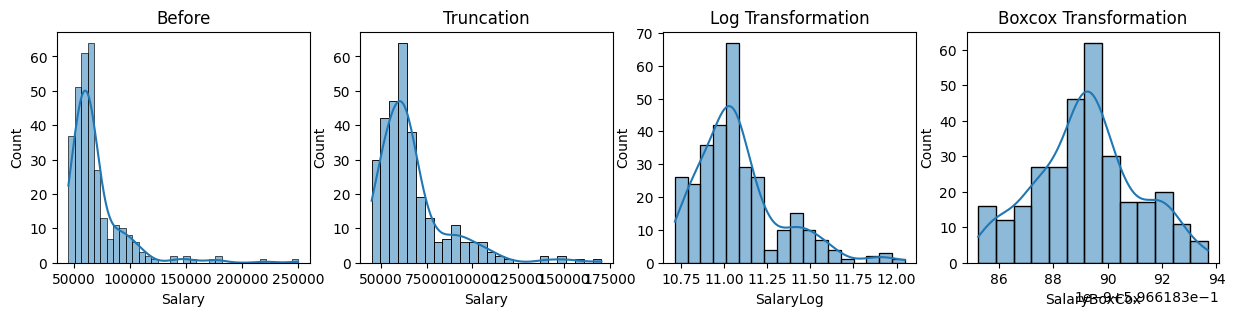

In [355]:
from scipy.stats import boxcox
from scipy import stats

y_trunc_ceiling = .99

# Let's look at the target variable distribution.
fig, axes = plt.subplots(1, 4, figsize=(15,3))

# HISTPLOT 1 -- No transformation
sns.histplot(df, x="Salary", ax=axes[0], kde=True)

# Truncation.
df = df[df["Salary"] <= df["Salary"].quantile(y_trunc_ceiling)]
sns.histplot(df, x="Salary", ax=axes[1], kde=True)  
    
# Log transormation. (This ended up getting thrown out, but it's still on the canvas)
df["SalaryLog"] = np.log1p(df["Salary"])
sns.histplot(df, x="SalaryLog", ax=axes[2], kde=True)

# BoxCox Transformation.
df["SalaryBoxCox"], lam = stats.boxcox(df["Salary"] + 1)
sns.histplot(df, x="SalaryBoxCox", ax=axes[3], kde=True)

# Setting titles.
axes[0].set_title("Before")
axes[1].set_title("Truncation")    
axes[2].set_title("Log Transformation")
axes[3].set_title("Boxcox Transformation")

# That will do!

# Let's drop the Log transformation column. We will use boxcox instead.
df = df.drop("SalaryLog", axis=1)

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">
<h3>Observations:</h3>

We can choose between Log Transformation and Boxcox Transformation. Let's use Boxcox here. It has a more normal bell curve and if we use it, we won't have to throw out a bunch more rows (we' don't have many as it is)
</div>

#### Creating Correlation Series to Select Features

Now, let's create some code that will select the features we'll want for our model. I know that `LassoCV` can do these steps below, but I'm doing it myself this time because of a few reasons:

1. I want to learn what goes on behind the hood
2. I need to be careful not to overfit here, since there's not really a lot of rows.
3. I want to select only X amount of features, just to have some element of control.

In [356]:
# The point of this is to select the features we'll want to use for our model.

# NOTE: I am pretty sure LassoCV does all of this(eliminate any low correlated features),
# but I want to do it manually 
# at least once, so I see the logic behind it.

# First, we make a correlation matrix.
correlation = df.corr(numeric_only=True).sort_values("Salary")

# Second, transform the dataframe so we ONLY see positive correlation values. 
abs_correlation = abs(correlation["Salary"])

# Third, we turn the filtered correlation series into a dataframe. Easier to work with.
abs_corr_df = pd.DataFrame(abs_correlation).reset_index()

# Fourth, we sort the values by the highest possible correlations. Start with the biggest corrs first.
abs_corr_df = abs_corr_df.sort_values("Salary", ascending=False)

# Finally, we just need to get get rid of the `Salary` and `SalaryBoxCox` correlation values.
# So here, we'll get rid of these 'data leak' gotcha columns.
abs_corr_df = abs_corr_df[
    (abs_corr_df["index"] != "Salary") &
    (abs_corr_df["index"] != "SalaryBoxCox")
]

# Renaming the columns, so it's nice and neat.
abs_corr_df = abs_corr_df.rename(columns={
    "Salary": "Absolute Value Correlation",
    "index": "Features"
})
abs_corr_df.head(10)

,Features,Absolute Value Correlation
30,SpecialProjectsCount,0.613969
29,Department_IT/IS,0.568341
0,Department_Production,0.547641
28,Department_Software Engineering,0.276199
27,DateofHire,0.229684
26,RecruitmentSource_Indeed,0.160127
1,RecruitmentSource_Google Search,0.145634
25,GenderID,0.118371
2,RecruitmentSource_LinkedIn,0.113028
24,RecruitmentSource_Employee Referral,0.099989


#### Creating a List of the Top Features

Now we have a dataframe with all the correlations, we'll put the top features into a list. We then call this list for the ML Implementation as:

`X = df[features_list]`

In [357]:
# Turns the features we want to use into a list.
features_list = list(abs_corr_df["Features"].head(9))
features_list

['SpecialProjectsCount',
 'Department_IT/IS',
 'Department_Production       ',
 'Department_Software Engineering',
 'DateofHire',
 'RecruitmentSource_Indeed',
 'RecruitmentSource_Google Search',
 'GenderID',
 'RecruitmentSource_LinkedIn']

#### Co-cardinality Check

This part checks to see if these features have any co-cardinality with one-another.

<Axes: >

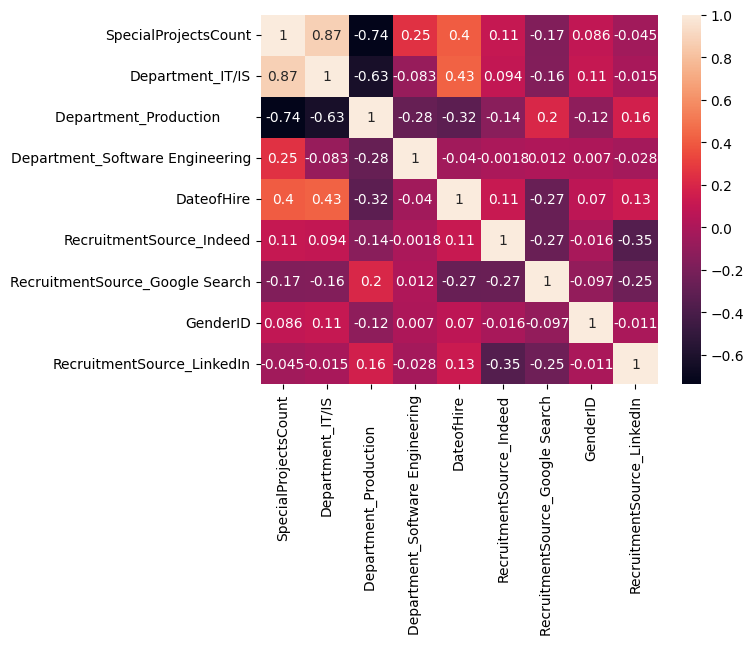

In [358]:
# Now we need to check for multi-collinearity. (If one column is dependent on another.)
# We're really just looking for high (.85 or above) linearity between these feature columns.
correlation = df[features_list].corr(numeric_only=True)
sns.heatmap(correlation, annot=True)

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">
<h3>Heatmap Observations</h3>

We've found a red-flag here. Take a look at `Department_IT/IS` vs. `SpecialProjectCount`. The correlation is `.87` , a seriously high correlation between those two features.

<b>This is probably textbook multi-collinearity. (I believe the cutoff is .9, so that's quite close)</b>

We should drop one of these columns. Let's drop `SpecialProjectsCount` since it has a high corr value with another feature too.

In [359]:
# Dropping the `SpecialProjectCount` column.
features_list.remove("SpecialProjectsCount")

In [360]:
# This is the completed list of features we'll be training our model with. Yay!
features_list

['Department_IT/IS',
 'Department_Production       ',
 'Department_Software Engineering',
 'DateofHire',
 'RecruitmentSource_Indeed',
 'RecruitmentSource_Google Search',
 'GenderID',
 'RecruitmentSource_LinkedIn']

---

### ML Implementation

|Step|Description|
|---|---|
|1|Data Cleaning |
|2|Transformation & Feature Engineering|
|3|<bold style="background:yellow;color:black;">   ML Implementation </bold>|


From here, we'll train training the model. As usual, I'll be using `mlflow` locally so I can track how well the model performed. Otherwise, I would be trying to remember what parameters and metrix _THAT ONE_ good run was.

In [361]:
from scipy.special import inv_boxcox
from sklearn.preprocessing import PolynomialFeatures

# We'll split the dataset by this amount and log it using mlflow.
XY_SPLIT = .3

# Supporting, target variable desclaration.
X = df[features_list]
y = df["SalaryBoxCox"]

# PolynomialFeatures transformation
# poly = PolynomialFeatures(2)
# X_poly = poly.fit_transform(X)

# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# Start MLFlow Experiment for logging.
mlflow.set_experiment("ex1_adv1")

with mlflow.start_run():
    
    # Model Creation
    lm = LinearRegression()
    lm.fit(X_train, y_train)
    
    # Predicting the unseen features.
    predictions = lm.predict(X_test)
    
    # REVERSES boxcox
    y_test = inv_boxcox(y_test, lam)
    predictions = inv_boxcox(predictions, lam)
    
    # -- METRICS RECORDING -- 
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r_sq = abs(metrics.r2_score(y_test, predictions))
    
    # -- MLFLOW LOGGING --
    mlflow.set_tag("dataset", "hr_data.csv")
    mlflow.set_tag("data_split", str(XY_SPLIT))
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("trunc_ceiling", y_trunc_ceiling)
    mlflow.log_param("PolynomialFeatures", False)
    mlflow.log_param("Features", features_list)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r_squared", r_sq)
    mlflow.sklearn.log_model(lm, "model")


2026/01/25 17:51:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [362]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
11802.54 

MSE
388064567.72 

RMSE
19699.35 

R-squared:
0.28 

PARAMETERS
--------------------------
X,Y Split:
0.3



#### y-test vs. predictions Scatterplot

<Axes: xlabel='SalaryBoxCox'>

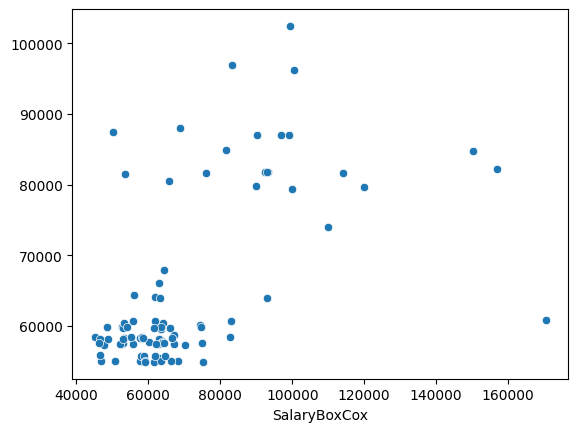

In [363]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

# Oh boy. Not really a straight line, is it? That's a disaster if I've ever seen one! 
# Though, surprisingly the metrics did very well. I'm satisfied with an MAE of 11k-12k
# I wonder how well it would do with `RandomForestRegressor`?

---

<b>NOTE:</b> The reast of the code is pretty much ONLY  personal analysis for the code. Feel free to skip it if you're not interested.

---

#### Creating a Dataframe Comparing Predictions to Test-Y



Let's create a dataframe that showed us what happened with the worst error margin cases.

In [364]:
# First, we create a dataframe with the predictions on it.
df_pred = pd.DataFrame(predictions)

# Second, we create another dataframe with the answers.
df_ytest = pd.DataFrame(y_test).reset_index()
df_ytest = df_ytest.drop("index", axis=1)

# Third, we create a dataframe with all the feature values.
df_test = pd.DataFrame(X_test).reset_index()
df_test = df_test.drop("index", axis=1)

# Now, we combine all three! Go, Go Power Rangers! (Megazord time)
df_test["SalaryPredicted"] = df_pred
df_test["Salary"] = df_ytest

# And to top it off, let's add an error margin column.
df_test["ErrorMargin"] = abs(df_test["Salary"] - df_test["SalaryPredicted"])

# Finally, we sort the values. 
df_test.sort_values("ErrorMargin", ascending=False).head(10)

# Now we can see what happened with the worst-predicted cases.



,Department_IT/IS,Department_Production,Department_Software Engineering,DateofHire,RecruitmentSource_Indeed,RecruitmentSource_Google Search,GenderID,RecruitmentSource_LinkedIn,SalaryPredicted,Salary,ErrorMargin
86,0,1,0,20090105,1,0,1,0,60886.252733,170500.999070,109614.746336
84,1,0,0,20120215,0,0,1,0,82223.680697,157000.997475,74777.316778
12,1,0,0,20170107,1,0,0,0,84724.897715,150290.997780,65566.100065
53,1,0,0,20150105,0,0,0,1,79618.504407,120000.998403,40382.493997
67,1,0,0,20150105,1,0,1,0,87397.570780,50179.000226,37218.570554
79,1,0,0,20140707,0,1,0,0,74043.820702,110000.997171,35957.176470
92,1,0,0,20150216,0,0,1,0,81660.051734,114000.002003,32339.950269
50,0,0,0,20160105,0,0,1,0,63936.369302,93046.998751,29110.629449
46,1,0,0,20150330,0,0,1,1,81495.290450,53367.000123,28128.290327
62,0,1,0,20110110,0,0,1,0,58463.871485,82759.000058,24295.128573


<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Observations</h3>

It appears that a lot of the bad error-margin cases are coming from the `Department_IT/IS` feature cases. I have a couple theories about that:

1. It could be that there is a wild variance between pay in IT/IS (some people get paid 30k, some get paid 130k)
2. It could also be our random seed for splitting wasn't great. Since it's 300 rows, it likely is quite volatile. And then it over/undervalues that features.
</div>